In [1]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score, \
                            adjusted_rand_score

In [2]:
iris = pd.read_csv('../csv/iris.csv')

In [3]:
x = iris.drop('species', axis = 1)
y = iris['species']

In [4]:
x_std = StandardScaler().fit_transform(x)

In [5]:
model = KMeans(
    n_clusters = 3,
    random_state = 42,
    n_init = 10
)

In [6]:
model.fit(x_std)
labels = model.predict(x_std)

In [7]:
labels

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 2, 2, 2, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 2,
       0, 0, 0, 0, 2, 0, 0, 0, 0, 2, 2, 2, 0, 0, 0, 0, 0, 0, 0, 2, 2, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 2, 2, 2, 2, 0, 2, 2, 2,
       2, 2, 2, 0, 0, 2, 2, 2, 2, 0, 2, 0, 2, 0, 2, 2, 0, 2, 2, 2, 2, 2,
       2, 0, 0, 2, 2, 2, 0, 2, 2, 2, 0, 2, 2, 2, 0, 2, 2, 0], dtype=int32)

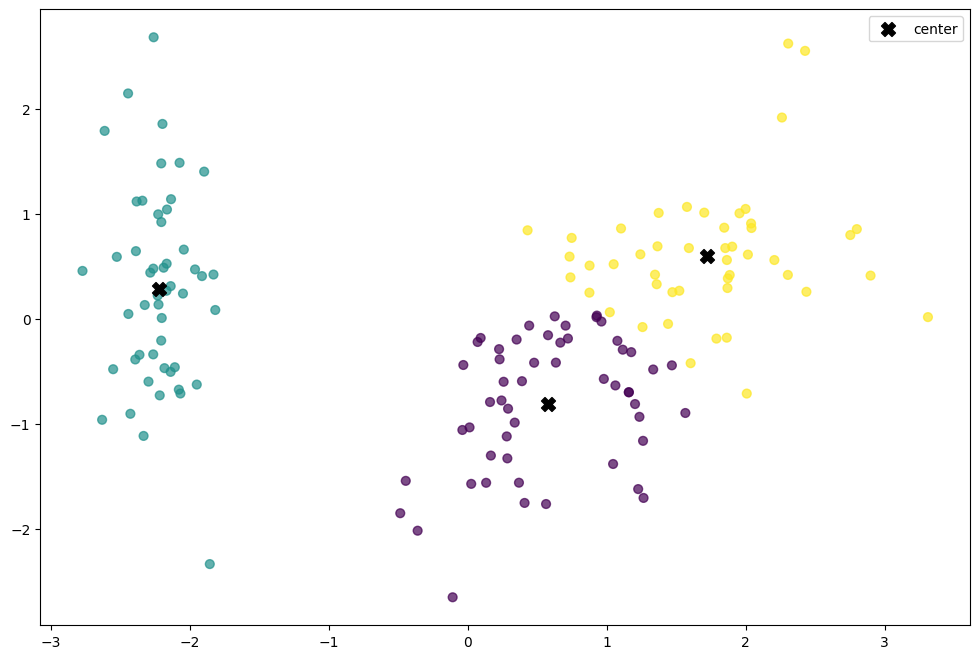

In [8]:
pca = PCA(n_components=2)
x_pca = pca.fit_transform(x_std)
center_pca = pca.transform(model.cluster_centers_)
plt.figure(figsize = (12, 8))
plt.scatter(
    x_pca[:, 0], x_pca[:, 1], c = labels, cmap = 'viridis', 
    s = 40, alpha=0.7
)
# 중심점을 산점도 
plt.scatter(
    center_pca[:, 0], center_pca[:, 1], c = 'black', s = 100, 
    marker = 'X', label = 'center'
)

plt.legend()
plt.show()